ARTI308 - Machine Learning

# Lab 6 Assignment: Linear Regression on Ecommerce Customers Dataset

**Dataset:** `Ecommerce_Customers.csv`  
**Goal:** Predict the **Yearly Amount Spent** by customers using Linear Regression.

---


## Step 1: Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

%matplotlib inline
sns.set(style="whitegrid")


## Step 2: Load the Dataset

We load the Ecommerce Customers CSV file into a pandas DataFrame.


In [21]:
df = pd.read_csv('/kaggle/input/datasets/munirahkhalid/ecommerce/Ecommerce Customers (1)')
df.head()


,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


## Step 3: Explore the Data

### 3.1 Basic Info


In [22]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


### 3.2 Statistical Summary

In [23]:
df.describe()


,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


### 3.3 Column Names

In [24]:
df.columns


Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

### 3.4 Check for Missing Values

In [25]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing values:", df.isnull().sum().sum())


Missing values per column:
Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

Total missing values: 0


**Observation:**  
The dataset has **500 rows** and **8 columns**. There are **no missing values**.  
The dataset contains:
- 3 text/categorical columns: `Email`, `Address`, `Avatar` — not useful for regression
- 4 numerical feature columns: `Avg. Session Length`, `Time on App`, `Time on Website`, `Length of Membership`
- 1 target column: `Yearly Amount Spent`


## Step 4: Exploratory Data Analysis (EDA)

### 4.1 Pairplot


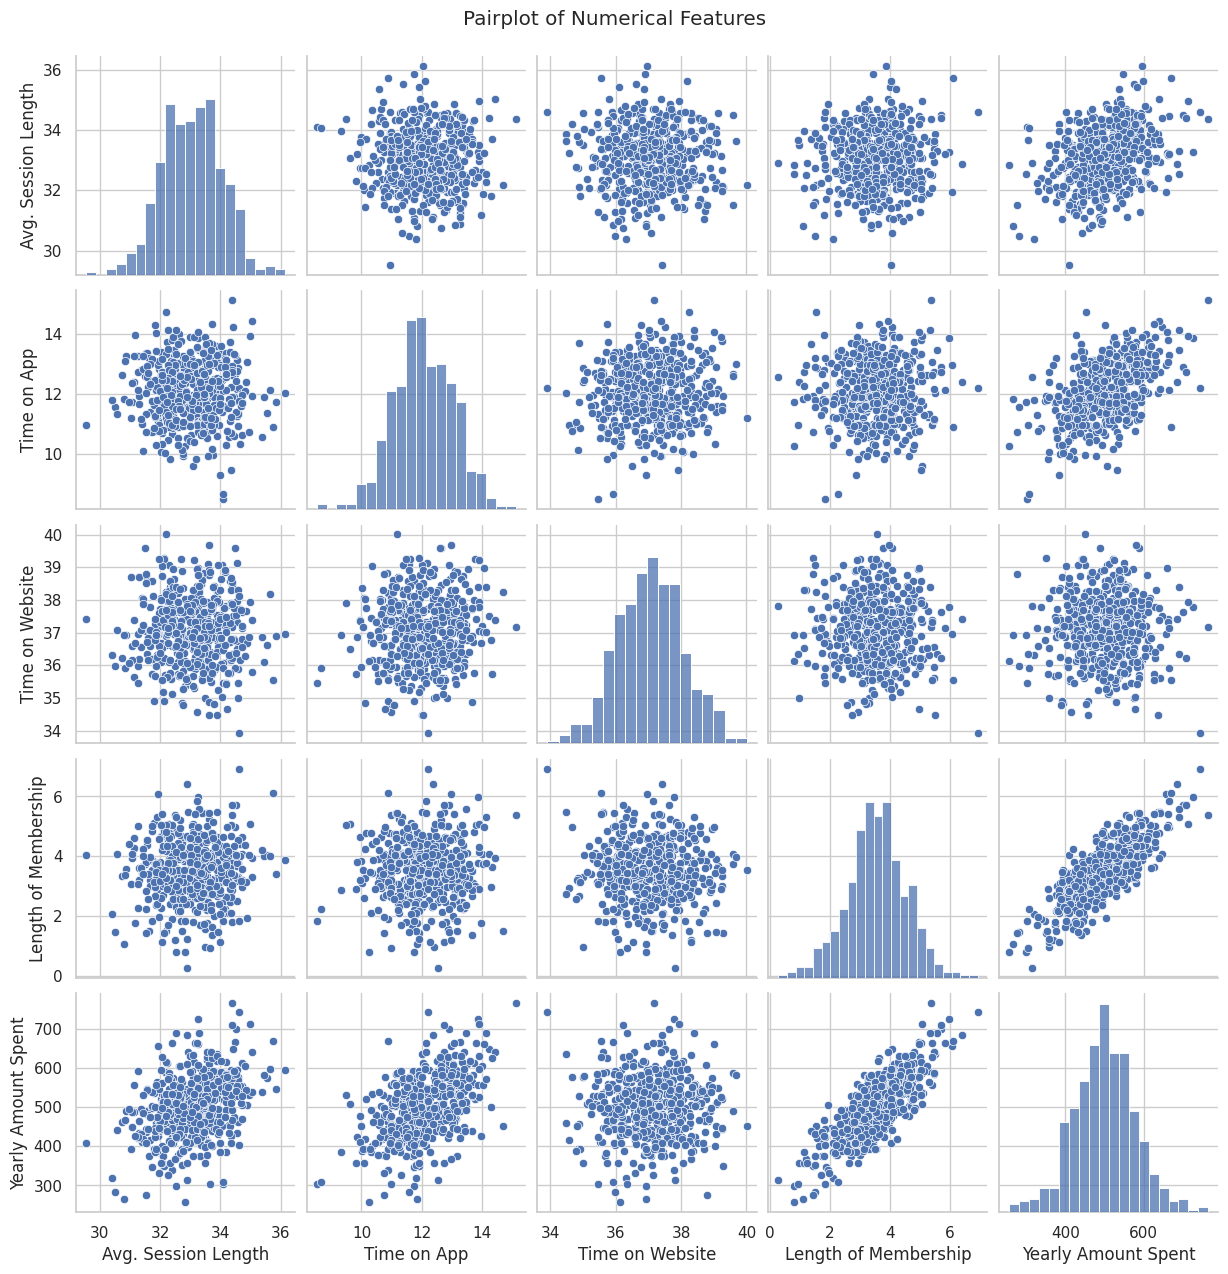

In [26]:
sns.pairplot(df[['Avg. Session Length', 'Time on App', 'Time on Website',
                 'Length of Membership', 'Yearly Amount Spent']])
plt.suptitle("Pairplot of Numerical Features", y=1.02)
plt.show()


**Observation:**  
The pairplot shows that **`Length of Membership`** and **`Time on App`** have strong linear relationships with `Yearly Amount Spent`. `Time on Website` appears to have a weaker relationship.


### 4.2 Distribution of Target Variable

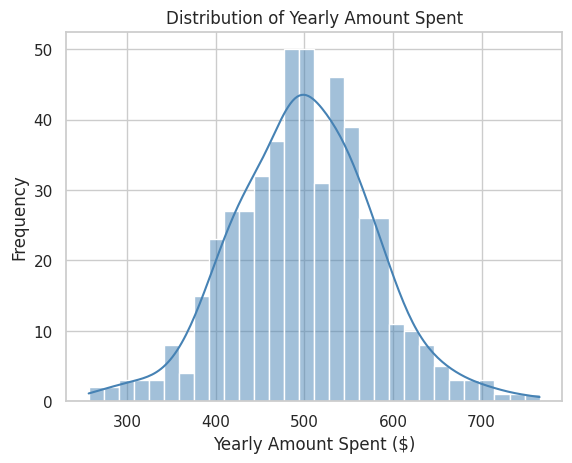

In [27]:
sns.histplot(df['Yearly Amount Spent'], kde=True, bins=30, color='steelblue')
plt.title("Distribution of Yearly Amount Spent")
plt.xlabel("Yearly Amount Spent ($)")
plt.ylabel("Frequency")
plt.show()


**Observation:**  
The target variable `Yearly Amount Spent` is approximately **normally distributed** with a mean around \$499. This is ideal for linear regression.


### 4.3 Correlation Heatmap

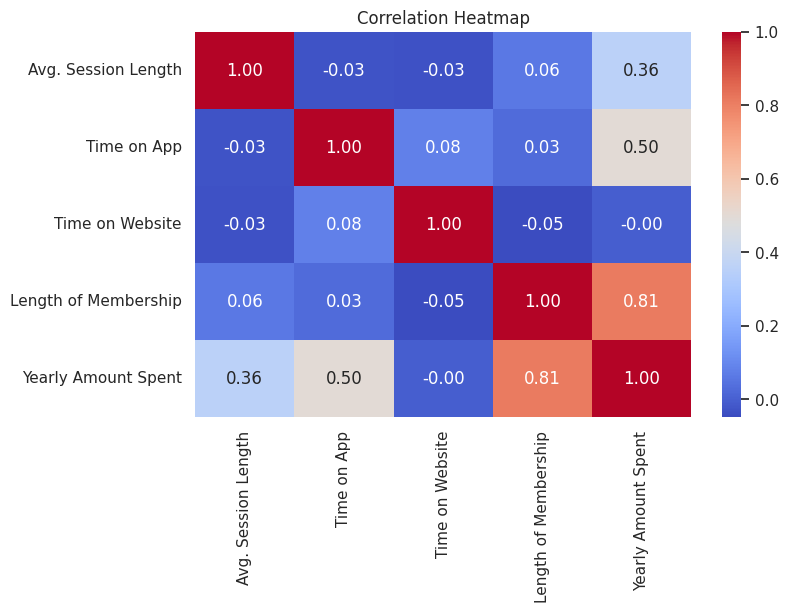

In [28]:
numeric_df = df[['Avg. Session Length', 'Time on App', 'Time on Website',
                  'Length of Membership', 'Yearly Amount Spent']]

plt.figure(figsize=(8, 5))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()


**Observation:**  
- `Length of Membership` has the **highest correlation** with `Yearly Amount Spent` (≈ 0.81)
- `Time on App` has a strong correlation (≈ 0.50)
- `Time on Website` has a very weak correlation (≈ 0.00) — almost no linear relationship
- `Avg. Session Length` has a moderate correlation (≈ 0.36)


## Step 5: Feature Engineering

The dataset is already clean (no missing values, no duplicates).  
We apply minimal feature engineering:

- **Drop non-numeric columns** (`Email`, `Address`, `Avatar`) — they carry no useful signal for linear regression
- The 4 numerical features are already well-scaled and ready for modeling
- No additional feature creation is needed for this dataset


In [29]:
# Drop non-numeric/ID-like columns
print("Columns to drop (non-numeric):", ['Email', 'Address', 'Avatar'])
print("\nFeature columns to use:", ['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership'])
print("Target column:", 'Yearly Amount Spent')


Columns to drop (non-numeric): ['Email', 'Address', 'Avatar']

Feature columns to use: ['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']
Target column: Yearly Amount Spent


## Step 6: Prepare Data for Modeling

### 6.1 Define Features (X) and Target (y)


In [30]:
X = df[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]
y = df['Yearly Amount Spent']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (500, 4)
Target vector shape: (500,)


### 6.2 Train-Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=101)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (300, 4)
Test set size: (200, 4)


We use **40% test / 60% train** split (same as the lab). `random_state=101` ensures reproducibility.


## Step 7: Train the Linear Regression Model


In [32]:
lm = LinearRegression()
lm.fit(X_train, y_train)

print("Model trained successfully!")
print("\nIntercept:", round(lm.intercept_, 4))


Model trained successfully!

Intercept: -1045.1152


In [33]:
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
print("Model Coefficients:")
coeff_df


Model Coefficients:


,Coefficient
Avg. Session Length,25.691540
Time on App,37.892600
Time on Website,0.560581
Length of Membership,61.648594


**Interpreting the Coefficients:**

- Holding all other features fixed, a 1 unit increase in **Avg. Session Length** is associated with an **increase of \$25.69**.
- Holding all other features fixed, a 1 unit increase in **Time on App** is associated with an **increase of \$37.89**.
- Holding all other features fixed, a 1 unit increase in **Time on Website** is associated with an **increase of \$0.56** (nearly negligible).
- Holding all other features fixed, a 1 unit increase in **Length of Membership** is associated with an **increase of \$61.65**.

> **Key Insight:** `Length of Membership` has by far the strongest positive impact on yearly spending, followed by `Time on App`. Interestingly, `Time on Website` has almost no impact — this might suggest the company should focus on improving its mobile app experience.


## Step 8: Evaluate the Model

### 8.1 Predictions vs Actual


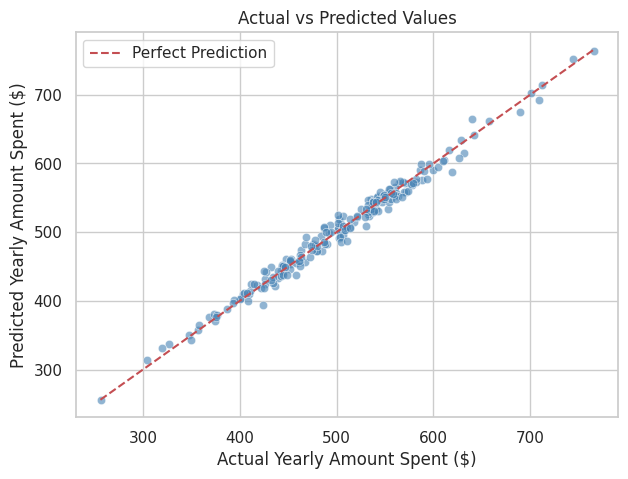

In [34]:
predictions = lm.predict(X_test)

plt.figure(figsize=(7, 5))
plt.scatter(y_test, predictions, alpha=0.6, color='steelblue', edgecolors='white', linewidth=0.5)
plt.xlabel("Actual Yearly Amount Spent ($)")
plt.ylabel("Predicted Yearly Amount Spent ($)")
plt.title("Actual vs Predicted Values")

# Perfect prediction line
min_val = min(y_test.min(), predictions.min())
max_val = max(y_test.max(), predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
plt.legend()
plt.show()


**Observation:**  
The scatter plot shows predictions closely following the diagonal red line (perfect prediction), indicating the model fits the data very well.


### 8.2 Residuals Analysis

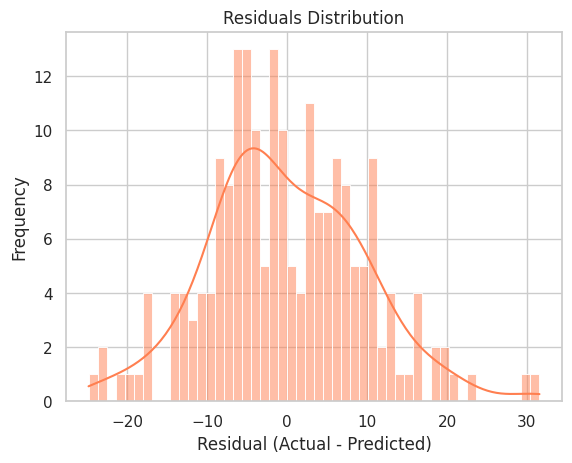

In [35]:
residuals = y_test - predictions

sns.histplot(residuals, kde=True, bins=50, color='coral')
plt.title("Residuals Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()


**Observation:**  
The residuals are approximately **normally distributed** and centered around **0**. This is a key assumption of linear regression and confirms the model is well-specified — there is no systematic bias in predictions.


### 8.3 Regression Evaluation Metrics

In [36]:
mae  = metrics.mean_absolute_error(y_test, predictions)
mse  = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2   = metrics.r2_score(y_test, predictions)

print(f"Mean Absolute Error  (MAE):  {mae:.4f}")
print(f"Mean Squared Error   (MSE):  {mse:.4f}")
print(f"Root Mean Sq. Error  (RMSE): {rmse:.4f}")
print(f"R² Score:                    {r2:.4f}")


Mean Absolute Error  (MAE):  7.7427
Mean Squared Error   (MSE):  93.8330
Root Mean Sq. Error  (RMSE): 9.6867
R² Score:                    0.9855


**Interpreting the Metrics:**

| Metric | Value | Meaning |
|--------|-------|---------|
| MAE | ~\$7.74 | On average, predictions are off by \$7.74 |
| MSE | ~93.83 | Average squared error |
| RMSE | ~\$9.69 | Predictions are off by ~\$9.69 on average (in same units as target) |
| R² | **~0.9855** | The model explains **98.55%** of the variance in `Yearly Amount Spent` |

**Conclusion:**  
The Linear Regression model performs **excellently** on this dataset. An R² of **0.9855** means the model captures nearly all variation in yearly spending from just 4 features. The low RMSE of ~\$9.69 on spending values ranging from ~\$256 to ~\$765 confirms high accuracy.
